# 🚢 Titanic - Machine Learning from Disaster

## Phase 5: Baseline Modeling & Cross-Validation

### Objective

The objective of this notebook is to establish a reliable machine learning evaluation framework and compare several baseline classification models using the feature-engineered Titanic dataset.

At this stage, our priority is **not hyperparameter tuning**.

Instead, we want to answer several fundamental questions:

1. Can our machine learning models outperform the majority-class baseline?
2. Which model families perform best with our engineered features?
3. How stable are model results across different validation folds?
4. Are some models showing signs of overfitting?
5. What types of classification errors does the strongest baseline model make?

To answer these questions reliably, we will use:

* Separate numerical and categorical feature groups.
* Scikit-learn preprocessing pipelines.
* One-hot encoding for categorical variables.
* Standardization of numerical variables where appropriate.
* Stratified K-Fold cross-validation.
* Out-of-fold predictions.
* Confusion matrices and classification reports.

## 1. Import Libraries

We begin by importing the libraries required

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import (
    LogisticRegression
)

from sklearn.tree import (
    DecisionTreeClassifier
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Feature-Engineered Data

We will load the datasets created and validated during Phase 4:

* `train_featured.csv`
* `test_featured.csv`

The training dataset contains the target variable `Survived`.

In [2]:
train = pd.read_csv(
    "/mnt/d/Acelin/Work/Code/titanic-kaggle/data/processed/train_featured.csv"
)

test = pd.read_csv(
    "/mnt/d/Acelin/Work/Code/titanic-kaggle/data/processed/test_featured.csv"
)

print("Feature-engineered datasets loaded successfully.")

print(
    f"Training shape: {train.shape}"
)

print(
    f"Test shape: {test.shape}"
)

Feature-engineered datasets loaded successfully.
Training shape: (891, 26)
Test shape: (418, 25)


## 3. Validate Modeling Data

Before training any model, we verify that:

* The target exists only in the training dataset.
* Passenger identifiers remain unique.
* Training and test datasets contain identical predictor columns.
* The target contains only the expected binary values.

In [3]:
assert "Survived" in train.columns

assert "Survived" not in test.columns

assert train["PassengerId"].is_unique

assert test["PassengerId"].is_unique

assert set(
    train.columns
) - {"Survived"} == set(
    test.columns
)

assert set(
    train["Survived"].unique()
).issubset({0, 1})

print(
    "Modeling dataset validation passed."
)

Modeling dataset validation passed.


## 4. Define the Target Variable

The competition target is:

`Survived`

where:

* `0` = Passenger did not survive.
* `1` = Passenger survived.

We will separate the target from the predictor variables before defining the modeling feature set.


In [4]:
y = train["Survived"].copy()

print(
    "Target distribution:"
)

print(
    y.value_counts()
)

print(
    "\nTarget percentages:"
)

print(
    y.value_counts(
        normalize=True
    )
    .mul(100)
    .round(2)
)

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Target percentages:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


## 5. Define the Baseline Feature Set

The feature-engineered dataset contains both original columns and newly created features.

Not every available column should be passed directly to the model.

We will exclude:

### `PassengerId`

This is primarily an identifier and does not have a meaningful continuous numerical relationship with survival.

### `Name`

The raw passenger name has very high cardinality. Useful information from it has already been represented through `Title`.

### `Ticket`

The raw ticket number also has high cardinality. We instead use `TicketGroupSize` and `TicketPrefix`.

### `Cabin`

Raw cabin strings are sparse and high-cardinality. We instead use `CabinKnown` and `Deck`.


In [5]:
numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone",
    "CabinKnown",
    "TicketGroupSize",
    "LogFare",
    "FarePerPerson",
    "AgeMissing",
    "IsChild"
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title",
    "FamilyCategory",
    "Deck",
    "TicketPrefix",
    "AgeGroup",
    "Sex_Pclass"
]

model_features = (
    numeric_features
    + categorical_features
)

X = train[
    model_features
].copy()

X_test = test[
    model_features
].copy()

print(
    f"Numerical features: "
    f"{len(numeric_features)}"
)

print(
    f"Categorical features: "
    f"{len(categorical_features)}"
)

print(
    f"Total model features: "
    f"{len(model_features)}"
)

print(
    f"\nX shape: {X.shape}"
)

print(
    f"X_test shape: {X_test.shape}"
)

Numerical features: 12
Categorical features: 9
Total model features: 21

X shape: (891, 21)
X_test shape: (418, 21)


In [6]:
print(
    "NUMERICAL FEATURES"
)

print("-" * 40)

for feature in numeric_features:
    print(
        f"- {feature}"
    )


print(
    "\nCATEGORICAL FEATURES"
)

print("-" * 40)

for feature in categorical_features:
    print(
        f"- {feature}"
    )

NUMERICAL FEATURES
----------------------------------------
- Age
- SibSp
- Parch
- Fare
- FamilySize
- IsAlone
- CabinKnown
- TicketGroupSize
- LogFare
- FarePerPerson
- AgeMissing
- IsChild

CATEGORICAL FEATURES
----------------------------------------
- Pclass
- Sex
- Embarked
- Title
- FamilyCategory
- Deck
- TicketPrefix
- AgeGroup
- Sex_Pclass


In [7]:
assert X.columns.tolist() == (
    X_test.columns.tolist()
)

assert X.shape[0] == train.shape[0]

assert X_test.shape[0] == test.shape[0]

assert X.shape[1] == len(
    model_features
)

print(
    "Feature selection validation passed."
)

Feature selection validation passed.


## 6. Check Missing Values Before Modeling

Although the engineered dataset was validated previously, we inspect missing values again before constructing the preprocessing pipeline.

The pipeline will still include imputers as a defensive measure.

This provides two benefits:

1. The pipeline remains robust if future feature-engineering experiments introduce missing values.
2. Preprocessing logic remains explicitly documented as part of the model.


In [8]:
missing_summary = (
    X.isna()
    .sum()
    .sort_values(
        ascending=False
    )
)

missing_summary[
    missing_summary > 0
]

Series([], dtype: int64)

# 7. Build the Preprocessing Pipeline

Machine learning models require numerical input, while our dataset contains both numerical and categorical variables.

We will create separate preprocessing pipelines.

## Numerical Pipeline

The numerical pipeline will:

1. Impute unexpected missing values using the median.
2. Standardize numerical variables.

Standardization is especially useful for models such as Logistic Regression.

Although tree-based models generally do not require scaling, using a common preprocessing pipeline allows us to compare several baseline models consistently.

## Categorical Pipeline

The categorical pipeline will:

1. Impute unexpected missing categories using the most frequent value.
2. Convert categories into numerical indicator variables using one-hot encoding.

`handle_unknown="ignore"` ensures that previously unseen categories do not cause prediction errors.

## Why Use a Pipeline?

Using a Scikit-learn pipeline ensures that preprocessing is fitted only on the training portion of each cross-validation fold.

This reduces data leakage and makes the modeling workflow reproducible.


In [9]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print(
    "Preprocessing pipeline created."
)

Preprocessing pipeline created.


# 8. Cross-Validation Strategy

The Titanic training dataset contains relatively few observations.

A single train-validation split may produce an unstable estimate because model performance can depend heavily on which passengers happen to appear in the validation set.

We will use **Stratified 5-Fold Cross-Validation**.

### How It Works

The training dataset is divided into five folds.

For each iteration:

* Four folds are used for training.
* One fold is used for validation.

This process is repeated until every fold has served as the validation set once.

### Why Stratification?

`StratifiedKFold` preserves approximately the same survival-class distribution in every fold.

### Why Shuffle?

Shuffling reduces the possibility that the original row ordering influences fold construction.

### Reproducibility

A fixed `random_state` ensures that all models are evaluated using exactly the same folds.


In [10]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(
    cv
)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


# 9. Establish a Dummy Baseline

Before evaluating real machine learning models, we need a reference point.

A `DummyClassifier` does not learn meaningful relationships between passenger features and survival.

Using the `most_frequent` strategy, it always predicts the majority class.

Any useful machine learning model should outperform this baseline consistently.

This provides a more formal version of the majority-class baseline identified during Phase 1.


In [11]:
dummy_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)


dummy_results = cross_validate(
    dummy_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    return_train_score=True,
    n_jobs=-1
)


print(
    "Dummy Classifier"
)

print(
    f"Mean Training Accuracy: "
    f"{dummy_results['train_score'].mean():.4f}"
)

print(
    f"Mean CV Accuracy: "
    f"{dummy_results['test_score'].mean():.4f}"
)

print(
    f"CV Standard Deviation: "
    f"{dummy_results['test_score'].std():.4f}"
)

Dummy Classifier
Mean Training Accuracy: 0.6162
Mean CV Accuracy: 0.6162
CV Standard Deviation: 0.0023


# 10. Define Baseline Machine Learning Models

We will compare several model families.

### Logistic Regression

A strong linear baseline for binary classification.

It provides a useful reference for determining whether complex nonlinear models are actually necessary.

### Decision Tree

A highly flexible model capable of learning nonlinear relationships and interactions.

An unrestricted decision tree can easily overfit, so comparing training and validation accuracy will be important.

### Random Forest

An ensemble of decision trees designed to improve generalization and reduce the instability of a single tree.

### Extra Trees

Similar to Random Forest but introduces additional randomness when constructing trees.

### Gradient Boosting

Builds trees sequentially, with each tree attempting to correct errors made by previous trees.

### HistGradientBoosting

A histogram-based gradient boosting implementation that can provide strong performance on tabular classification problems.

At this stage, we use mostly default or conservative parameters.

The objective is model-family comparison, not optimization.


In [12]:
models = {
    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "Hist Gradient Boosting":
        HistGradientBoostingClassifier(
            random_state=42
        )
}

print(
    f"Number of baseline models: "
    f"{len(models)}"
)

Number of baseline models: 6


# 11. Evaluate Baseline Models

Each model will be placed inside the same preprocessing pipeline and evaluated using the same cross-validation folds.

For every model, we will record:

* Mean training accuracy.
* Mean cross-validation accuracy.
* Cross-validation standard deviation.
* Minimum fold accuracy.
* Maximum fold accuracy.
* Difference between training and validation accuracy.

The difference between training and validation performance provides a simple indication of potential overfitting.

A large positive gap suggests that the model fits the training data substantially better than unseen validation data.


In [13]:
results = []

model_pipelines = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                model
            )
        ]
    )

    model_pipelines[name] = pipeline

    cv_results = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        return_train_score=True,
        n_jobs=-1
    )

    train_mean = (
        cv_results[
            "train_score"
        ].mean()
    )

    cv_mean = (
        cv_results[
            "test_score"
        ].mean()
    )

    cv_std = (
        cv_results[
            "test_score"
        ].std()
    )

    results.append({
        "Model": name,
        "Train Accuracy": train_mean,
        "Mean CV Accuracy": cv_mean,
        "CV Std": cv_std,
        "Min CV Accuracy":
            cv_results[
                "test_score"
            ].min(),
        "Max CV Accuracy":
            cv_results[
                "test_score"
            ].max(),
        "Train-CV Gap":
            train_mean - cv_mean
    })

    print(
        f"{name:<25} "
        f"Train: {train_mean:.4f} | "
        f"CV: {cv_mean:.4f} "
        f"(± {cv_std:.4f})"
    )

Logistic Regression       Train: 0.8499 | CV: 0.8260 (± 0.0173)
Decision Tree             Train: 0.9927 | CV: 0.8125 (± 0.0228)
Random Forest             Train: 0.9927 | CV: 0.8372 (± 0.0144)
Extra Trees               Train: 0.9927 | CV: 0.8159 (± 0.0237)
Gradient Boosting         Train: 0.9175 | CV: 0.8350 (± 0.0159)
Hist Gradient Boosting    Train: 0.9742 | CV: 0.8361 (± 0.0163)


In [14]:
results_df = (
    pd.DataFrame(
        results
    )
    .sort_values(
        by="Mean CV Accuracy",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

results_df.round(4)

,Model,Train Accuracy,Mean CV Accuracy,CV Std,Min CV Accuracy,Max CV Accuracy,Train-CV Gap
0,Random Forest,0.9927,0.8372,0.0144,0.8202,0.8547,0.1555
1,Hist Gradient Boosting,0.9742,0.8361,0.0163,0.8146,0.8603,0.1381
2,Gradient Boosting,0.9175,0.8350,0.0159,0.8202,0.8547,0.0825
3,Logistic Regression,0.8499,0.8260,0.0173,0.7978,0.8492,0.0239
4,Extra Trees,0.9927,0.8159,0.0237,0.7865,0.8547,0.1768
5,Decision Tree,0.9927,0.8125,0.0228,0.7697,0.8324,0.1802


In [15]:
dummy_row = pd.DataFrame({
    "Model": [
        "Dummy Classifier"
    ],
    "Train Accuracy": [
        dummy_results[
            "train_score"
        ].mean()
    ],
    "Mean CV Accuracy": [
        dummy_results[
            "test_score"
        ].mean()
    ],
    "CV Std": [
        dummy_results[
            "test_score"
        ].std()
    ],
    "Min CV Accuracy": [
        dummy_results[
            "test_score"
        ].min()
    ],
    "Max CV Accuracy": [
        dummy_results[
            "test_score"
        ].max()
    ],
    "Train-CV Gap": [
        dummy_results[
            "train_score"
        ].mean()
        -
        dummy_results[
            "test_score"
        ].mean()
    ]
})


comparison_df = (
    pd.concat(
        [
            results_df,
            dummy_row
        ],
        ignore_index=True
    )
    .sort_values(
        "Mean CV Accuracy",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

comparison_df.round(4)

,Model,Train Accuracy,Mean CV Accuracy,CV Std,Min CV Accuracy,Max CV Accuracy,Train-CV Gap
0,Random Forest,0.9927,0.8372,0.0144,0.8202,0.8547,0.1555
1,Hist Gradient Boosting,0.9742,0.8361,0.0163,0.8146,0.8603,0.1381
2,Gradient Boosting,0.9175,0.8350,0.0159,0.8202,0.8547,0.0825
3,Logistic Regression,0.8499,0.8260,0.0173,0.7978,0.8492,0.0239
4,Extra Trees,0.9927,0.8159,0.0237,0.7865,0.8547,0.1768
5,Decision Tree,0.9927,0.8125,0.0228,0.7697,0.8324,0.1802
6,Dummy Classifier,0.6162,0.6162,0.0023,0.6124,0.6180,-0.0000


## 11.1 Compare Cross-Validation Accuracy

We will visualize the mean cross-validation accuracy of each model.

The purpose of this visualization is not simply to select the model with the highest score.

We should also consider:

* Score variability across folds.
* Training-validation gap.
* Model complexity.
* Stability.
* Interpretability.

A very small difference in mean accuracy may not represent a meaningful performance difference, particularly when cross-validation variability is relatively large.


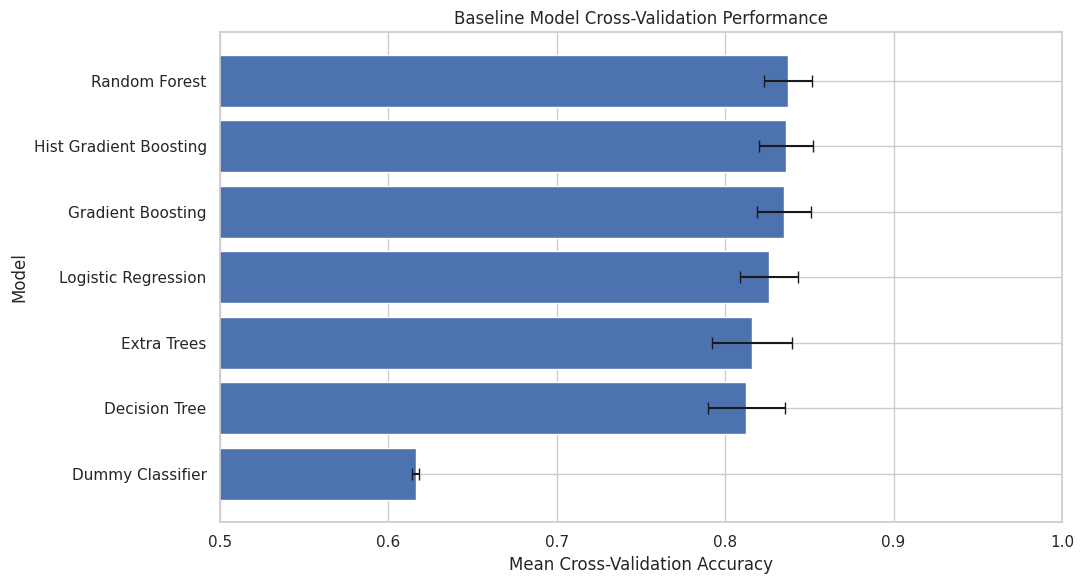

In [16]:
plt.figure(
    figsize=(11, 6)
)

plot_df = (
    comparison_df
    .sort_values(
        "Mean CV Accuracy",
        ascending=True
    )
)

plt.barh(
    plot_df["Model"],
    plot_df["Mean CV Accuracy"],
    xerr=plot_df["CV Std"],
    capsize=4
)

plt.xlabel(
    "Mean Cross-Validation Accuracy"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Baseline Model Cross-Validation Performance"
)

plt.xlim(
    0.5,
    1.0
)

plt.tight_layout()

plt.show()

# 12. Training vs Cross-Validation Performance

High training accuracy does not necessarily indicate a strong model.

A model that performs extremely well on its training data but substantially worse during cross-validation may be overfitting.

We will compare:

`Training Accuracy - Cross-Validation Accuracy`

A larger gap suggests greater potential overfitting.

This is only a diagnostic rather than a formal measure, but it helps identify models that may require stronger regularization or parameter constraints.


In [17]:
overfitting_df = (
    results_df[
        [
            "Model",
            "Train Accuracy",
            "Mean CV Accuracy",
            "Train-CV Gap"
        ]
    ]
    .sort_values(
        "Train-CV Gap",
        ascending=False
    )
)

overfitting_df.round(4)

,Model,Train Accuracy,Mean CV Accuracy,Train-CV Gap
5,Decision Tree,0.9927,0.8125,0.1802
4,Extra Trees,0.9927,0.8159,0.1768
0,Random Forest,0.9927,0.8372,0.1555
1,Hist Gradient Boosting,0.9742,0.8361,0.1381
2,Gradient Boosting,0.9175,0.8350,0.0825
3,Logistic Regression,0.8499,0.8260,0.0239


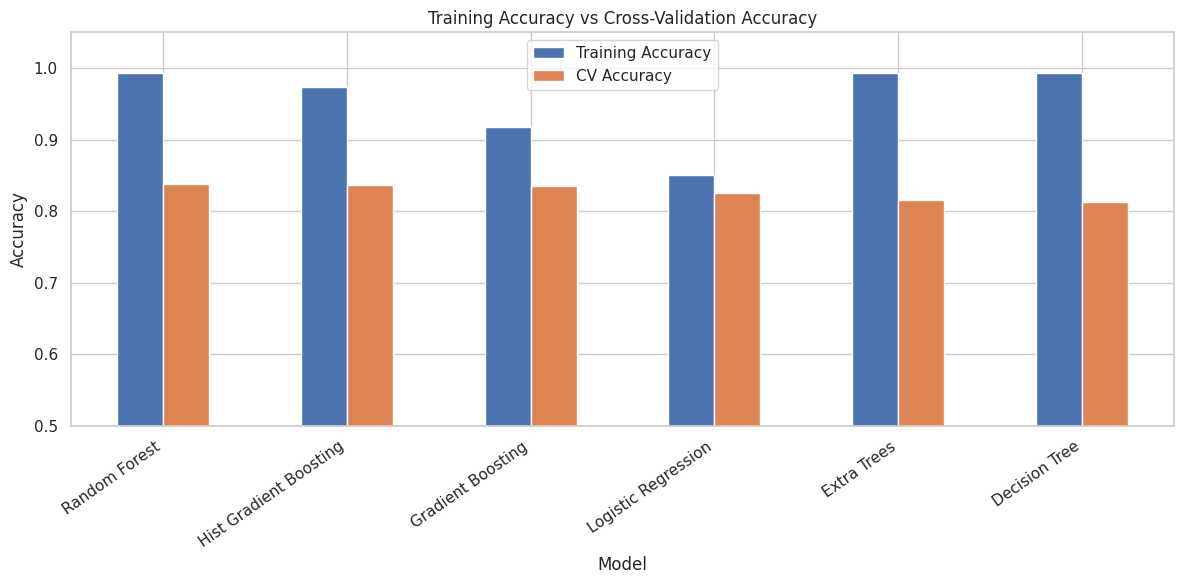

In [18]:
plot_data = (
    results_df[
        [
            "Model",
            "Train Accuracy",
            "Mean CV Accuracy"
        ]
    ]
    .set_index(
        "Model"
    )
)

plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Training Accuracy vs Cross-Validation Accuracy"
)

plt.ylabel(
    "Accuracy"
)

plt.xlabel(
    "Model"
)

plt.ylim(
    0.5,
    1.05
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.legend(
    [
        "Training Accuracy",
        "CV Accuracy"
    ]
)

plt.tight_layout()

plt.show()

# 13. Identify the Strongest Baseline Model

We will identify the model with the highest mean cross-validation accuracy.

This model is considered the strongest baseline under the current feature set and validation strategy.

However, it should not automatically be considered the final competition model.

Models with similar cross-validation performance may still perform differently after:

* Feature selection.
* Hyperparameter tuning.
* Repeated cross-validation.
* Ensemble construction.

The strongest baseline will primarily be used for detailed error analysis.


In [19]:
best_model_name = (
    results_df
    .iloc[0]["Model"]
)

best_cv_accuracy = (
    results_df
    .iloc[0][
        "Mean CV Accuracy"
    ]
)

best_model = (
    model_pipelines[
        best_model_name
    ]
)

print(
    f"Best baseline model: "
    f"{best_model_name}"
)

print(
    f"Mean CV accuracy: "
    f"{best_cv_accuracy:.4f}"
)

Best baseline model: Random Forest
Mean CV accuracy: 0.8372


# 14. Out-of-Fold Predictions

Cross-validation gives us an estimate of model performance, but we also want to examine the model's individual prediction errors.

We will generate **out-of-fold predictions**.

For every passenger, the prediction is generated by a model that was not trained on that passenger.

This gives us a more realistic set of training-data predictions for error analysis than simply fitting a model on the entire training dataset and predicting the same observations.


In [20]:
oof_predictions = (
    cross_val_predict(
        best_model,
        X,
        y,
        cv=cv,
        method="predict",
        n_jobs=-1
    )
)


oof_accuracy = accuracy_score(
    y,
    oof_predictions
)


print(
    f"Out-of-Fold Accuracy: "
    f"{oof_accuracy:.4f}"
)

Out-of-Fold Accuracy: 0.8373


## 14.1 Confusion Matrix

The confusion matrix shows the types of classification errors made by the model.

It contains four outcomes:

* **True Negative:** Correctly predicted non-survivor.
* **False Positive:** Predicted survival when the passenger did not survive.
* **False Negative:** Predicted non-survival when the passenger survived.
* **True Positive:** Correctly predicted survivor.

This provides more information than accuracy alone.


In [21]:
cm = confusion_matrix(
    y,
    oof_predictions
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual: Did Not Survive",
        "Actual: Survived"
    ],
    columns=[
        "Predicted: Did Not Survive",
        "Predicted: Survived"
    ]
)

cm_df

,Predicted: Did Not Survive,Predicted: Survived
Actual: Did Not Survive,489,60
Actual: Survived,85,257


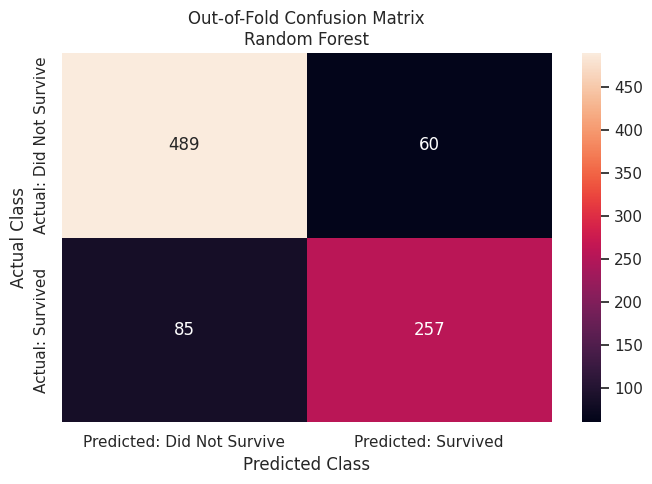

In [22]:
plt.figure(
    figsize=(7, 5)
)

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d"
)

plt.title(
    f"Out-of-Fold Confusion Matrix\n"
    f"{best_model_name}"
)

plt.ylabel(
    "Actual Class"
)

plt.xlabel(
    "Predicted Class"
)

plt.tight_layout()

plt.show()

In [23]:
print(
    classification_report(
        y,
        oof_predictions,
        target_names=[
            "Did Not Survive",
            "Survived"
        ]
    )
)

                 precision    recall  f1-score   support

Did Not Survive       0.85      0.89      0.87       549
       Survived       0.81      0.75      0.78       342

       accuracy                           0.84       891
      macro avg       0.83      0.82      0.83       891
   weighted avg       0.84      0.84      0.84       891



# 15. Create an Error Analysis Dataset

To understand where the strongest baseline model fails, we will create a dataset containing:

* Passenger information.
* Actual survival outcome.
* Out-of-fold prediction.
* Whether the prediction was correct.

This allows us to inspect misclassified passengers and search for patterns that may motivate future feature-engineering experiments.

Because predictions are generated out-of-fold, this analysis provides a more realistic view of model errors.


In [24]:
error_analysis = train[
    [
        "PassengerId",
        "Name",
        "Sex",
        "Age",
        "Pclass",
        "Fare",
        "Title",
        "FamilySize",
        "TicketGroupSize",
        "Deck",
        "Survived"
    ]
].copy()


error_analysis[
    "Predicted"
] = oof_predictions


error_analysis[
    "Correct"
] = (
    error_analysis[
        "Survived"
    ]
    ==
    error_analysis[
        "Predicted"
    ]
)


print(
    "Correct predictions:"
)

print(
    error_analysis[
        "Correct"
    ]
    .value_counts()
)

Correct predictions:
Correct
True     746
False    145
Name: count, dtype: int64


In [25]:
misclassified = (
    error_analysis[
        ~error_analysis[
            "Correct"
        ]
    ]
    .copy()
)


print(
    f"Total misclassified passengers: "
    f"{len(misclassified)}"
)


display(
    misclassified.head(20)
)

Total misclassified passengers: 145


,PassengerId,Name,Sex,Age,Pclass,Fare,Title,FamilySize,TicketGroupSize,Deck,Survived,Predicted,Correct
14,15,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,3,7.8542,Miss,1,1,Unknown,0,1,False
17,18,"Williams, Mr. Charles Eugene",male,30.0,2,13.0000,Mr,1,1,Unknown,1,0,False
18,19,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",female,31.0,3,18.0000,Mrs,2,2,Unknown,0,1,False
21,22,"Beesley, Mr. Lawrence",male,34.0,2,13.0000,Mr,1,1,D,1,0,False
22,23,"McGowan, Miss. Anna ""Annie""",female,15.0,3,8.0292,Miss,1,1,Unknown,1,0,False
23,24,"Sloper, Mr. William Thompson",male,28.0,1,35.5000,Mr,1,1,A,1,0,False
25,26,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,3,31.3875,Mrs,7,7,Unknown,1,0,False
36,37,"Mamee, Mr. Hanna",male,26.0,3,7.2292,Mr,1,1,Unknown,1,0,False
38,39,"Vander Planke, Miss. Augusta Maria",female,18.0,3,18.0000,Miss,3,2,Unknown,0,1,False
39,40,"Nicola-Yarred, Miss. Jamila",female,14.0,3,11.2417,Miss,2,2,Unknown,1,0,False


In [26]:
error_by_sex = (
    error_analysis
    .groupby(
        "Sex"
    )["Correct"]
    .agg(
        [
            "count",
            "mean"
        ]
    )
)

error_by_sex[
    "Error_Rate"
] = (
    1
    -
    error_by_sex[
        "mean"
    ]
)

error_by_sex.round(4)

,count,mean,Error_Rate
Sex,,,
female,314,0.8280,0.1720
male,577,0.8423,0.1577


In [27]:
error_by_class = (
    error_analysis
    .groupby(
        "Pclass"
    )["Correct"]
    .agg(
        [
            "count",
            "mean"
        ]
    )
)

error_by_class[
    "Error_Rate"
] = (
    1
    -
    error_by_class[
        "mean"
    ]
)

error_by_class.round(4)

,count,mean,Error_Rate
Pclass,,,
1,216,0.7917,0.2083
2,184,0.9130,0.0870
3,491,0.8289,0.1711


In [28]:
error_by_title = (
    error_analysis
    .groupby(
        "Title"
    )["Correct"]
    .agg(
        [
            "count",
            "mean"
        ]
    )
)

error_by_title[
    "Error_Rate"
] = (
    1
    -
    error_by_title[
        "mean"
    ]
)

error_by_title.sort_values(
    "Error_Rate",
    ascending=False
).round(4)

,count,mean,Error_Rate
Title,,,
Rare,23,0.6522,0.3478
Miss,185,0.8108,0.1892
Mr,517,0.8414,0.1586
Mrs,126,0.8492,0.1508
Master,40,0.9750,0.0250


# 16. Baseline Modeling Evaluation

After running the models, the results table should be used to evaluate each candidate across three dimensions.

### 1. Predictive Performance

Compare mean cross-validation accuracy.

A higher value indicates better average performance across validation folds.

### 2. Stability

Compare cross-validation standard deviation.

A model with slightly lower mean accuracy but substantially lower variability may be more reliable than an unstable model with a marginally higher average.

### 3. Overfitting

Compare training accuracy with cross-validation accuracy.

A large training-validation gap suggests that the model may be memorizing patterns in the training data that do not generalize well.

### Model Selection Principle

We should avoid selecting a final model solely because it ranks first by a very small difference in mean cross-validation accuracy.

If multiple models perform similarly, they should all remain candidates for:

* Feature-ablation experiments.
* Hyperparameter tuning.
* Repeated cross-validation.
* Ensemble modeling.


# 17. Save Baseline Model Results

We will save the baseline cross-validation results for future comparison.

This creates a permanent benchmark.

Future experiments involving feature selection, hyperparameter tuning, or advanced models should demonstrate measurable improvement over these baseline results.


In [29]:
from pathlib import Path


results_dir = Path(
    "/mnt/d/Acelin/Work/Code/titanic-kaggle/results"
)

results_dir.mkdir(
    parents=True,
    exist_ok=True
)


results_df.to_csv(
    results_dir /
    "baseline_model_results.csv",
    index=False
)


print(
    "Baseline results saved to:"
)

print(
    "../results/baseline_model_results.csv"
)

Baseline results saved to:
../results/baseline_model_results.csv


In [30]:
error_analysis.to_csv(
    results_dir /
    "baseline_oof_predictions.csv",
    index=False
)


print(
    "Out-of-fold predictions saved to:"
)

print(
    "../results/baseline_oof_predictions.csv"
)

Out-of-fold predictions saved to:
../results/baseline_oof_predictions.csv


# 18. Phase 5 Summary

In this notebook, we established the first reliable machine learning benchmark for the Titanic competition.

## Data Preparation

We loaded the feature-engineered datasets created during Phase 4 and explicitly selected candidate model features.

High-cardinality raw identifiers were excluded from direct modeling:

* `PassengerId`
* `Name`
* `Ticket`
* `Cabin`

Useful information extracted from these columns was retained through engineered features.

## Preprocessing Pipeline

We created a Scikit-learn preprocessing pipeline that:

* Handles numerical features.
* Handles categorical features.
* Imputes unexpected missing values.
* Standardizes numerical variables.
* One-hot encodes categorical variables.

Because preprocessing is contained inside the model pipeline, transformations are fitted independently within each cross-validation training fold.

## Cross-Validation

We used Stratified 5-Fold Cross-Validation with shuffling and a fixed random seed.

This provides a more reliable estimate of model generalization than relying on a single train-validation split.

## Dummy Baseline

A majority-class `DummyClassifier` established the minimum benchmark that meaningful machine learning models should outperform.

## Baseline Models

We evaluated several model families:

* Logistic Regression
* Decision Tree
* Random Forest
* Extra Trees
* Gradient Boosting
* Hist Gradient Boosting

All models were evaluated using identical cross-validation folds.

## Model Diagnostics

For each model, we examined:

* Mean training accuracy.
* Mean cross-validation accuracy.
* Cross-validation variability.
* Minimum and maximum fold performance.
* Training-validation performance gap.

This helped us evaluate both predictive performance and potential overfitting.

## Out-of-Fold Error Analysis

For the strongest baseline model, we generated out-of-fold predictions.

These predictions were used to examine:

* Overall accuracy.
* Confusion matrix.
* Precision.
* Recall.
* F1-score.
* Misclassified passengers.
* Error patterns across sex, passenger class, and title.

## Baseline Benchmark

The results from this notebook represent our initial machine learning benchmark.

We should not yet assume that the highest-scoring baseline model is the final competition model.
